# Statistical Analysis of Financial Returns

This stage investigates the statistical properties of asset returns. Understanding these properties helps determine appropriate models for volatility forecasting.

Key objectives:

1. Understand the statistical behavior of financial returns
2. Identify volatility clustering patterns
3. Verify stationarity of the time series
4. Analyze temporal dependencies in the data

These insights guide the selection of suitable volatility models in later stages.

step 1: returns the distribution

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
sp500 = pd.read_csv("../data/SP500_processed.csv", index_col="Date", parse_dates=True)
btc = pd.read_csv("../data/BTC_processed.csv", index_col="Date", parse_dates=True)

In [7]:
sp500.head()

,Open,High,Low,Close,Volume,log_return,vol_30
Date,,,,,,,
2014-01-03,149.238532,149.539900,148.749847,148.961609,81390600,-0.000164,NaN
2014-01-06,149.450282,149.507290,148.301852,148.529907,108028200,-0.002902,NaN
2014-01-07,149.124474,149.694612,149.010446,149.442123,86144200,0.006123,NaN
2014-01-08,149.417742,149.727251,148.961631,149.474762,96582300,0.000218,NaN
2014-01-09,149.955259,149.971552,148.888282,149.572449,90683400,0.000653,NaN


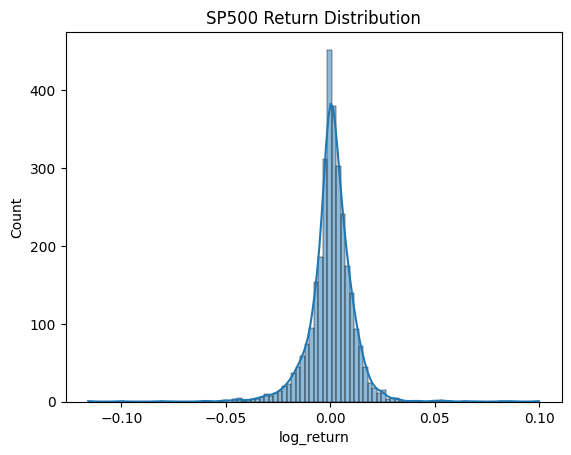

In [8]:
sns.histplot(sp500["log_return"], bins=100, kde=True)
plt.title("SP500 Return Distribution")
plt.show()

step 2:volatitlity clustering

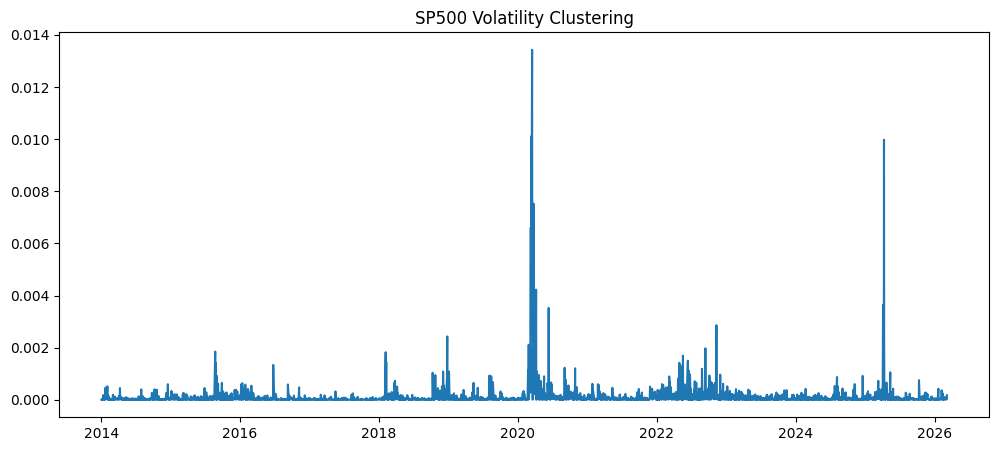

In [9]:
plt.figure(figsize=(12,5))
plt.plot(sp500["log_return"]**2)
plt.title("SP500 Volatility Clustering")
plt.show()

step 3:stationarity test

In [10]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(sp500["log_return"])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -18.02564033713839
p-value: 2.6864479950847978e-30


step 4:autocorrection

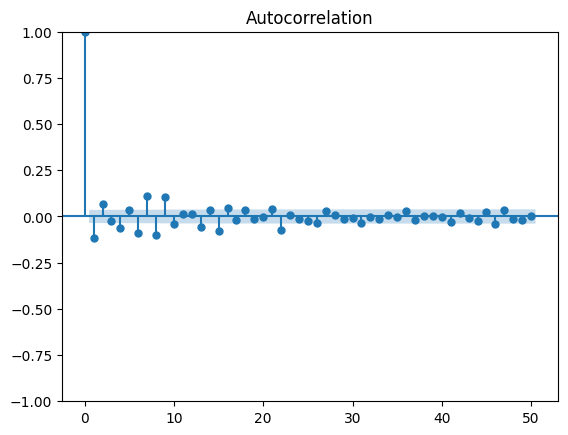

In [11]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(sp500["log_return"], lags=50)
plt.show()